In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
# --- State Definition ---
class PersonaState(TypedDict):
    name: str
    designation: str
    query: str
    response: str
# --- Nodes ---
def introduce_agent(state: PersonaState):
    print(f"Hi, I am {state['name']}, your {state['designation']}.")
    return state
# --- Graph Construction ---
graph = StateGraph(PersonaState)
graph.add_node("intro", introduce_agent)
graph.add_edge(START, "intro")
graph.add_edge("intro", END)
# --- Execution ---
app = graph.compile()
app.invoke({"name": "FinBot", "designation": "Personal Finance Advisor", "query": "What are good saving plans?"})


Hi, I am FinBot, your Personal Finance Advisor.


{'name': 'FinBot',
 'designation': 'Personal Finance Advisor',
 'query': 'What are good saving plans?'}

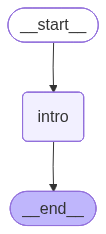

In [2]:
app

In [5]:
def handle_usecase(state: PersonaState):
    if "invest" in state["query"].lower():
        state["response"] = "As your finance advisor, I suggest diversified mutual funds."
    else:
        state["response"] = "Let's discuss your financial goals."
    return state
graph.add_node("usecase", handle_usecase)
graph.add_edge("intro", "usecase")
graph.add_edge("usecase", END)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [6]:
class PersonaConfig(TypedDict):
    name: str
    designation: str
    purpose: str
    problem: str
def describe_purpose(state: PersonaConfig):
    print(f"I am {state['name']} ({state['designation']}). My purpose is {state['purpose']}. I solve: {state['problem']}")
    return state


In [8]:

from typing import List
class ResourceState(TypedDict):
    data_sources: List[str]
    apis: List[str]
    permissions: List[str]
def check_resources(state: ResourceState):
    print(f" Data Sources: {state['data_sources']}")
    print(f"APIs: {state['apis']}")
    print(f"Permissions: {state['permissions']}")
    return state


In [10]:
from langgraph.graph import StateGraph, START, END
# --- Sub-agents ---
def planner_node(state):
    state["plan"] = "Collect user preferences and create itinerary."
    return state
def executor_node(state):
    print(f"Executing: {state['plan']}")
    return state
# --- Main Graph ---
main = StateGraph(dict)
main.add_node("planner", planner_node)
main.add_node("executor", executor_node)
main.add_edge(START, "planner")
main.add_edge("planner", "executor")
main.add_edge("executor", END)
app = main.compile()
app.invoke({})


Executing: Collect user preferences and create itinerary.


{'plan': 'Collect user preferences and create itinerary.'}

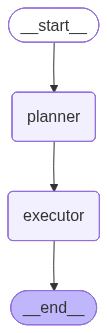

In [11]:
app